# 3.8 Comparison of Importance Sampling Methods - Figures

In [1]:
library(here)
source(here("setup.R"))

here() starts at /Users/stefan/workspace/work/phd/thesis



## Data

In [2]:
df_ef <- read_csv(here("data/figures/ef_meis_cem_ssms.csv"))

df_eps <- read_csv(here("data/figures/gsmm_eps.csv"))

fixed_s2 = read_csv(here("data/figures/fixed_s2.csv"))
fixed_mu = read_csv(here("data/figures/fixed_mu.csv"))

## Breakdown of methods

### `tikz/gssm_eps.tex`

Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_line()`).”


agg_record_2024325771 
                    2

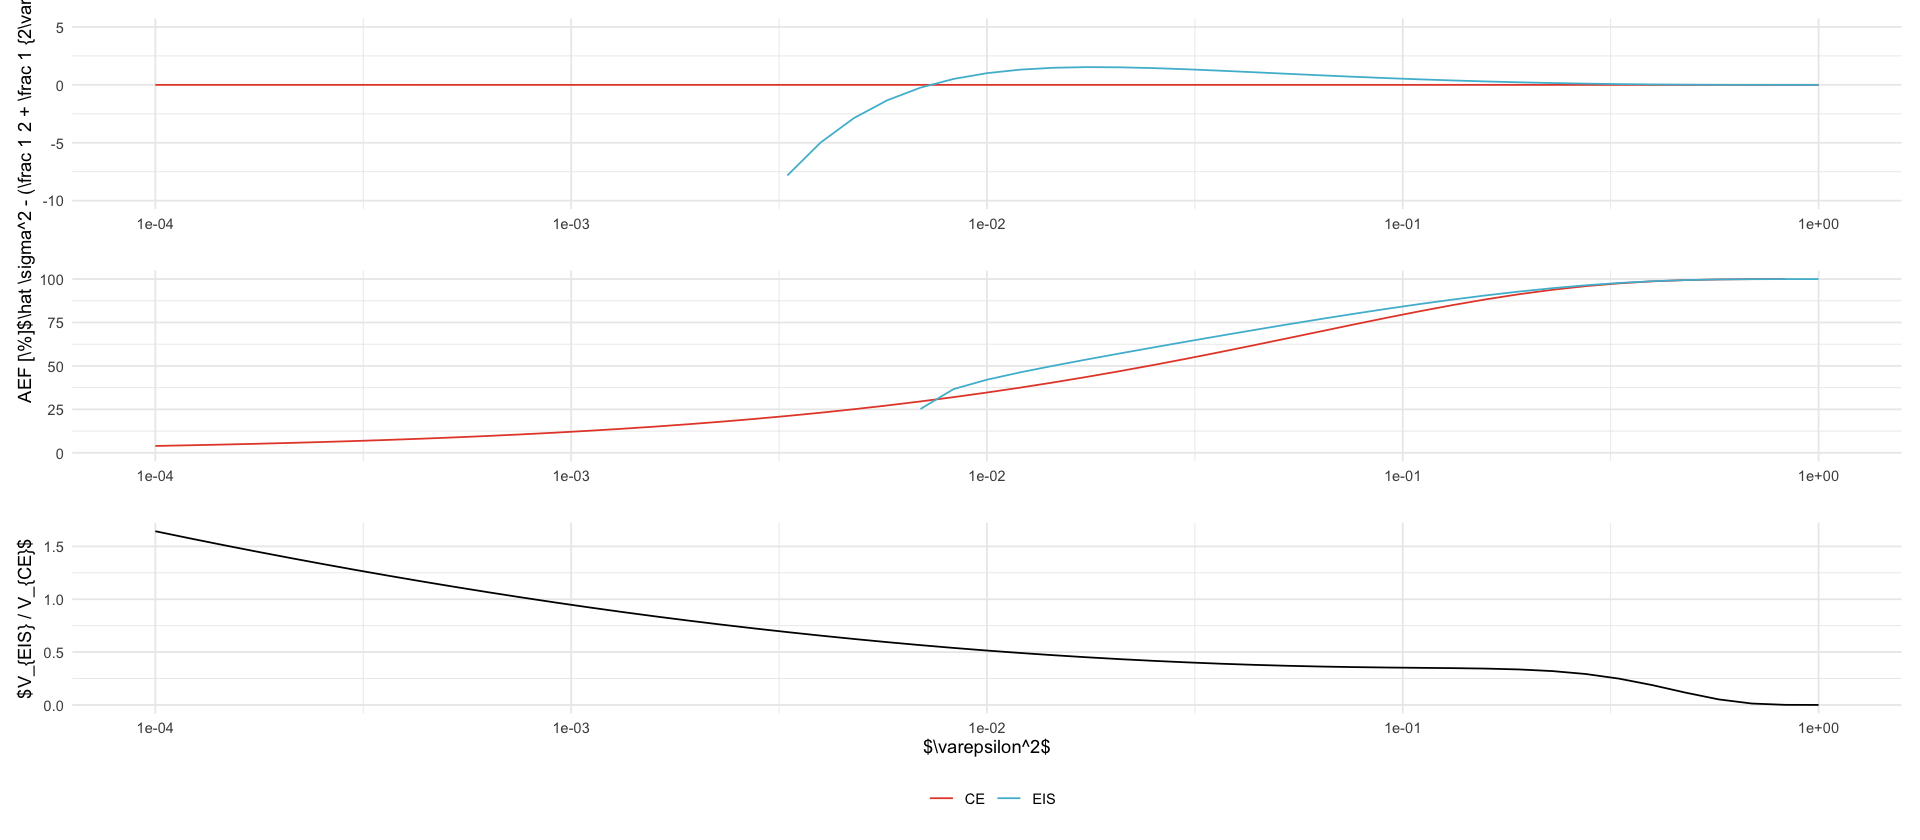

In [3]:
p1 <- df_eps %>%
    select(epsilon, sigma2_cem, sigma2_eis) %>%
    pivot_longer(-epsilon, names_pattern = "sigma2_(.*)", values_to = "sigma2") %>%
    mutate(name = ifelse(name == "cem", "CE", "EIS")) %>%
    ggplot(aes(epsilon**2, sigma2 - (1 / 2 + 1 / 2 / epsilon**2), color = name)) +
    geom_line() +
    scale_x_log10() +
    # scale_y_log10() +
    scale_color_discrete(name = "") +
    labs(x = "", y = "$\\hat \\sigma^2 - (\\frac 1 2 + \\frac 1 {2\\varepsilon^2})$") +
    ylim(-10, 5)

p2 <- df_eps %>%
    select(epsilon, starts_with("rho")) %>%
    pivot_longer(-epsilon, names_pattern = "rho_(.*)", values_to = "rho") %>%
    mutate(name = ifelse(name == "cem", "CE", "EIS")) %>%
    ggplot(aes(epsilon**2, 1 / rho * 100, color = name)) +
    geom_line() +
    scale_x_log10() +
    labs(x = "", y = "AEF [\\%]") +
    scale_color_discrete(name = "") +
    ylim(0, 100)

p3 <- df_eps %>%
    select(epsilon, are) %>%
    ggplot(aes(epsilon**2, are)) +
    geom_line() +
    scale_x_log10() +
    labs(x = "$\\varepsilon^2$", y = "$V_{EIS} / V_{CE}$") +
    theme(legend.position = "bottom")

(p1 / p2 / p3) + plot_layout(guides = "collect") & theme(legend.position = "bottom")
ggsave_tikz(here("tikz/gsmm_eps.tex"))


## Ratio of asymptotic variances

In [4]:
targets_meta = read_csv(here("data/figures/fixed_mu_s2_target_meta.csv")) %>%
    mutate(type = case_when(
        str_detect(P, "location") ~ "location mixture",
        str_detect(P, "scale") ~ "scale mixture",
        TRUE ~ "normal"
    ))  %>%
    mutate(type = factor(type, levels=c("normal", "location mixture", "scale mixture"))) %>%
    mutate(description = case_when(
        str_detect(P, "location") ~ str_glue("{param_name} = {param_value}"),
        str_detect(P, "scale") ~ str_glue("{param_name} = {param_value}"),
        TRUE ~ "$\\mathcal N(0,1)$"
    ))  %>%
    mutate(description = factor(description)) %>%
    mutate(description = fct_relevel(
        description, 
        "$\\mathcal N(0,1)$",
        "$\\omega^2$ = 1",
        "$\\omega^2$ = 0.5",
        "$\\omega^2$ = 0.1",
        "$\\varepsilon^2$ = 2",
        "$\\varepsilon^2$ = 10",
        "$\\varepsilon^2$ = 100"
    )) 

In [5]:

target_linetypes <- scale_linetype_manual(
    values = c(
        "$\\mathcal N(0,1)$" = "solid",
        "$\\omega^2$ = 1" = "solid",
        "$\\omega^2$ = 0.5" = "dashed",
        "$\\omega^2$ = 0.1" = "dotted",
        "$\\varepsilon^2$ = 2" = "solid",
        "$\\varepsilon^2$ = 10" = "dashed",
        "$\\varepsilon^2$ = 100" = "dotted"
    ),
)
global_shared_geoms <- list(
    facet_wrap(~type, ncol = 1),
    target_linetypes
)

shared_geoms <- list(
    coord_cartesian(ylim = c(1e-2, 1e2)),
    scale_y_log10(breaks = 10^(c(-2, 0, 2)), labels = paste0("$10^{", c(-2, 0, 2), "}$")),
    labs(y = "$\\frac{V_{EIS}}{V_{CE}}$", color="", linetype="")
)

### `tikz/are.tex`

Warning message in scale_y_log10(breaks = 10^(c(-2, 0, 2)), labels = paste0("$10^{", :
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_vline()`).”
Warning message in scale_y_log10(breaks = 10^(c(-2, 0, 2)), labels = paste0("$10^{", :
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_vline()`).”


agg_record_1848955551 
                    2

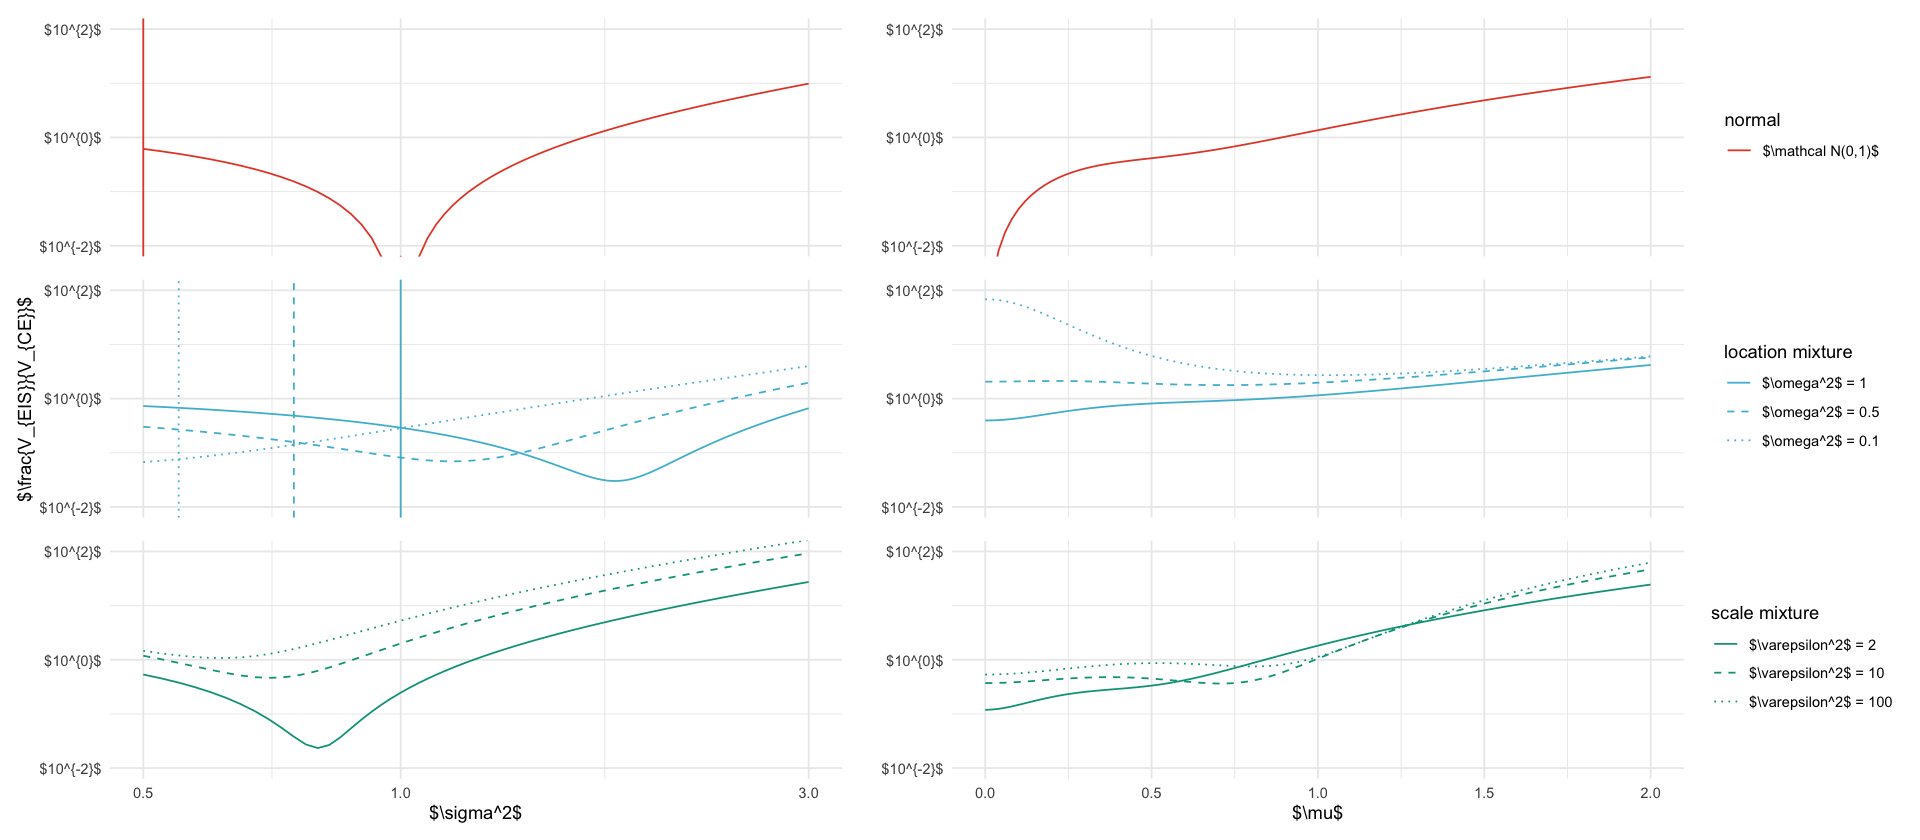

In [6]:
# NPG colors from ggsci
npg_colors <- c("#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4", "#91D1C2", "#DC0000", "#7E6148", "#B09C85")

# Define color palettes for each type
colors_normal <- c("$\\mathcal N(0,1)$" = npg_colors[1])

colors_location <- c(
    "$\\omega^2$ = 1" = npg_colors[2],
    "$\\omega^2$ = 0.5" = npg_colors[2],
    "$\\omega^2$ = 0.1" = npg_colors[2]
)

colors_scale <- c(
    "$\\varepsilon^2$ = 2" = npg_colors[3],
    "$\\varepsilon^2$ = 10" = npg_colors[3],
    "$\\varepsilon^2$ = 100" = npg_colors[3]
)

plots <- bind_rows(
    fixed_s2 %>% mutate(id = "fixed_s2"),
    fixed_mu %>% mutate(id = "fixed_mu")
) %>%
    inner_join(targets_meta, by="P") %>%
    #select(id, type, mu, s2, description, var_ratio) %>%
    group_by(type) %>%
    nest() %>%
    mutate(
        data_fixed_s2 = map(data, ~ filter(.x, id == "fixed_s2")),
        data_fixed_mu = map(data, ~ filter(.x, id == "fixed_mu")),
        data = NULL,
        colors = case_when(
            type == "normal" ~ list(colors_normal),
            type == "location mixture" ~ list(colors_location),
            type == "scale mixture" ~ list(colors_scale)
        )
    ) %>%
    ungroup() %>%
    mutate(row_idx = row_number(), n_rows = n()) %>%
    mutate(
        plot = pmap(list(type, data_fixed_s2, data_fixed_mu, colors, row_idx, n_rows), function(type, data_fixed_s2, data_fixed_mu, colors, row_idx, n_rows) {
            color_scale <- scale_color_manual(values = colors)

            is_last <- row_idx == n_rows
            is_middle <- row_idx == ceiling(n_rows / 2)
            legend_title <- as.character(type)
            
            x_axis_theme <- if (!is_last) {
                theme(axis.title.x = element_blank(), axis.text.x = element_blank(), axis.ticks.x = element_blank())
            } else {
                theme()
            }
            
            y_label <- if (is_middle) "$\\frac{V_{EIS}}{V_{CE}}$" else ""
            
            p_s2 <- ggplot(data_fixed_s2, aes(x=s2, y=var_ratio, color=description, linetype=description)) +
                geom_line() +
                geom_vline(aes(xintercept = tau2/2, color=description, linetype=description), data = data_fixed_s2 %>% filter(abs(s2 - tau2/2) == min(abs(s2-tau2/2))), show.legend = FALSE) +
                shared_geoms +
                target_linetypes +
                color_scale +
                labs(x="$\\sigma^2$", y=y_label, color=legend_title, linetype=legend_title) +
                theme(legend.position = "bottom") +
                x_axis_theme + 
                scale_x_log10(limits = c(1/2, 3))
            
            p_mu <- ggplot(data_fixed_mu, aes(x=mu, y=var_ratio, color=description, linetype=description)) +
                geom_line() +
                shared_geoms +
                target_linetypes +
                color_scale +
                labs(x="$\\mu$", y="", color=legend_title, linetype=legend_title) +
                theme(legend.position = "bottom") +
                x_axis_theme
            
            (p_s2 | p_mu) + plot_layout(guides = "collect") & theme(legend.position = "right")
         }
        )
    )
    

# add manual legend at the bottom: 'x' = $\\sigma^2 = \\tau^2/2$ for fixed $\\mu$ and $\\mu = 0$ for fixed $\\sigma^2$
(plots$plot[[1]] / plots$plot[[2]] / plots$plot[[3]])
ggsave_tikz(here("tikz/are.tex"), width=8, height= 10)

### `tikz/targets.tex`

agg_record_242350412 
                   2

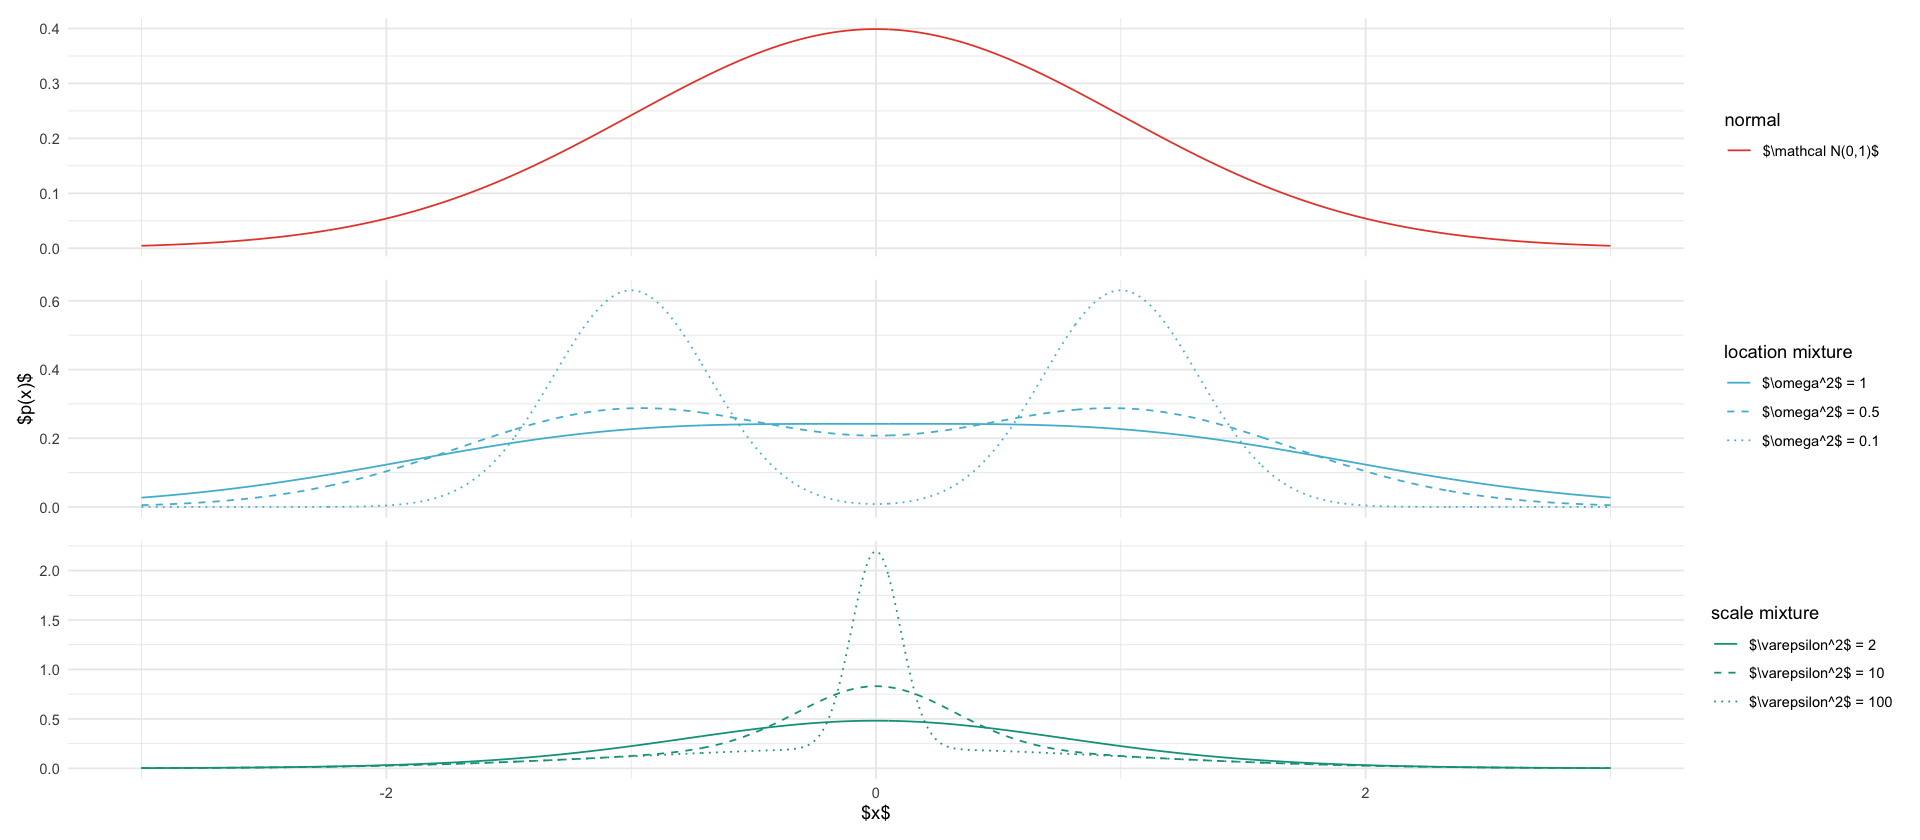

In [7]:
xs <- seq(-3, 3, length.out=1000)

gmm_location <- function(omega2) {
    function(x) {
        0.5 * dnorm(x, mean=-1, sd=sqrt(omega2)) + 0.5 * dnorm(x, mean=1, sd=sqrt(omega2))
    }
}

gmm_scale <- function(eps2) {
    function(x) {
        0.5 * dnorm(x, mean=0, sd=1) + 0.5 * dnorm(x, mean=0, sd=1/sqrt(eps2))
    }
}

targets <- tibble(
    "Normal" = dnorm(xs, mean=0, sd=1),
    "GMM_location_0.10" = gmm_location(0.1)(xs),
    "GMM_location_0.50" = gmm_location(0.5)(xs),
    "GMM_location_1.00" = gmm_location(1.0)(xs),
    "GMM_scale_2.00" = gmm_scale(2.0)(xs),
    "GMM_scale_10.00" = gmm_scale(10.0)(xs),
    "GMM_scale_100.00" = gmm_scale(100.0)(xs),
    x =  xs
)

target_plots <- targets %>% 
    pivot_longer(-x) %>% 
    inner_join(targets_meta, by=c("name"="P")) %>%
    group_by(type) %>%
    nest() %>%
    mutate(
        colors = case_when(
            type == "normal" ~ list(colors_normal),
            type == "location mixture" ~ list(colors_location),
            type == "scale mixture" ~ list(colors_scale)
        )
    ) %>%
    ungroup() %>%
    mutate(row_idx = row_number(), n_rows = n()) %>%
    mutate(
        plot = pmap(list(type, data, colors, row_idx, n_rows), function(type, data, colors, row_idx, n_rows) {
            color_scale <- scale_color_manual(values = colors)
            
            is_last <- row_idx == n_rows
            is_middle <- row_idx == ceiling(n_rows / 2)
            legend_title <- as.character(type)
            
            x_axis_theme <- if (!is_last) {
                theme(axis.title.x = element_blank(), axis.text.x = element_blank(), axis.ticks.x = element_blank())
            } else {
                theme()
            }
            
            y_label <- if (is_middle) "$p(x)$" else ""
            
            ggplot(data, aes(x=x, y=value, color=description, linetype=description)) +
                geom_line() +
                target_linetypes +
                color_scale +
                labs(x="$x$", y=y_label, color=legend_title, linetype=legend_title) +
                theme(legend.position = "right") +
                x_axis_theme
        })
    )

target_plots$plot[[1]] / target_plots$plot[[2]] / target_plots$plot[[3]]

ggsave_tikz(here("tikz/targets.tex"), width=8, height= 5)

### `tikz/cem_eis_sigma2.tex`

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 23 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 187 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 23 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 23 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 187 rows containing missing values or values outside the scale range
(`geom_line(

agg_record_727638325 
                   2

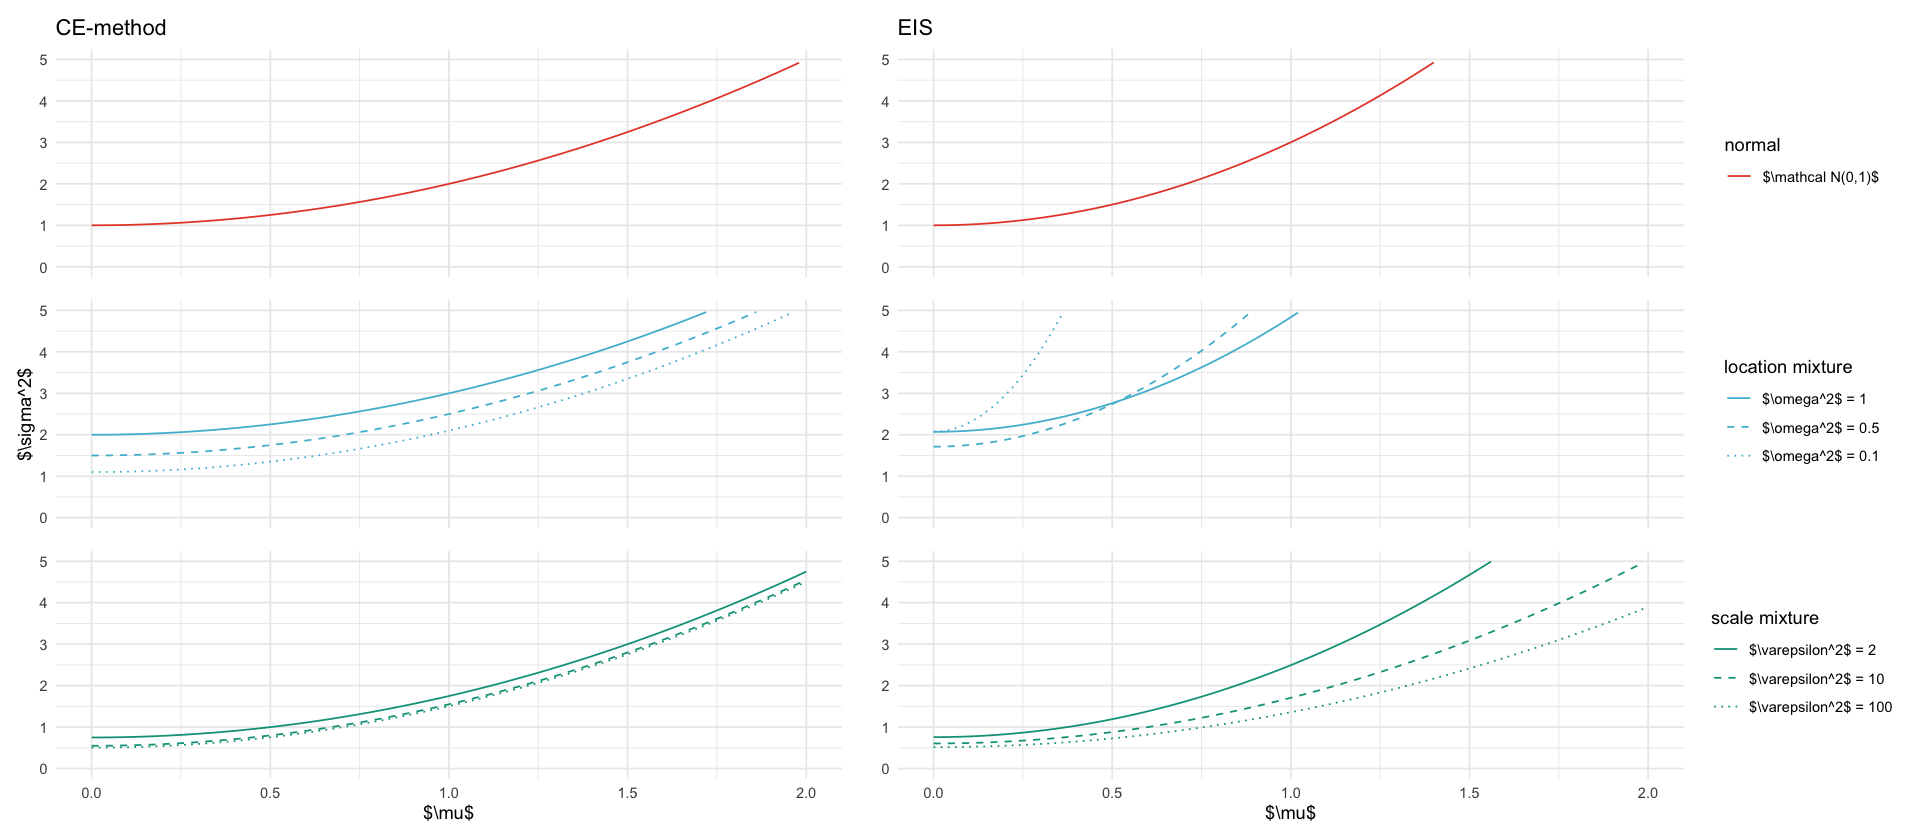

In [8]:
s2_plots <- fixed_mu %>%
    inner_join(targets_meta, by="P") %>%
    group_by(type) %>%
    nest() %>%
    mutate(
        colors = case_when(
            type == "normal" ~ list(colors_normal),
            type == "location mixture" ~ list(colors_location),
            type == "scale mixture" ~ list(colors_scale)
        )
    ) %>%
    ungroup() %>%
    mutate(row_idx = row_number(), n_rows = n()) %>%
    mutate(
        plot = pmap(list(type, data, colors, row_idx, n_rows), function(type, data, colors, row_idx, n_rows) {
            color_scale <- scale_color_manual(values = colors)
            
            is_first <- row_idx == 1
            is_middle <- row_idx == ceiling(n_rows / 2)
            is_last <- row_idx == n_rows
            legend_title <- as.character(type)
            
            x_axis_theme <- if (!is_last) {
                theme(axis.title.x = element_blank(), axis.text.x = element_blank(), axis.ticks.x = element_blank())
            } else {
                theme()
            }
            
            title_ce <- if (is_first) "CE-method" else NULL
            title_eis <- if (is_first) "EIS" else NULL
            
            y_label <- if (is_middle) "$\\sigma^2$" else ""
            
            p_s2_ce <- ggplot(data, aes(x=mu, y=s2_ce, color=description, linetype=description)) +
                geom_line() +
                target_linetypes +
                color_scale +
                labs(x="$\\mu$", y=y_label, color=legend_title, linetype=legend_title) +
                ylim(0, 5) +
                ggtitle(title_ce) +
                theme(legend.position = "bottom") +
                x_axis_theme
            
            p_s2_eis <- ggplot(data, aes(x=mu, y=s2_eis, color=description, linetype=description)) +
                geom_line() +
                target_linetypes +
                color_scale +
                labs(x="$\\mu$", y="", color=legend_title, linetype=legend_title) +
                ylim(0, 5) +
                ggtitle(title_eis) +
                theme(legend.position = "bottom") +
                x_axis_theme
            
            (p_s2_ce | p_s2_eis) + plot_layout(guides = "collect") & theme(legend.position = "right")
        })
    )

s2_plots$plot[[1]] / s2_plots$plot[[2]] / s2_plots$plot[[3]]

ggsave_tikz(here("tikz/cem_eis_sigma2.tex"), width=8, height= 5)

### `tikz/ssm_comparison_asymptotic_variance.tex`

agg_record_1713157937 
                    2

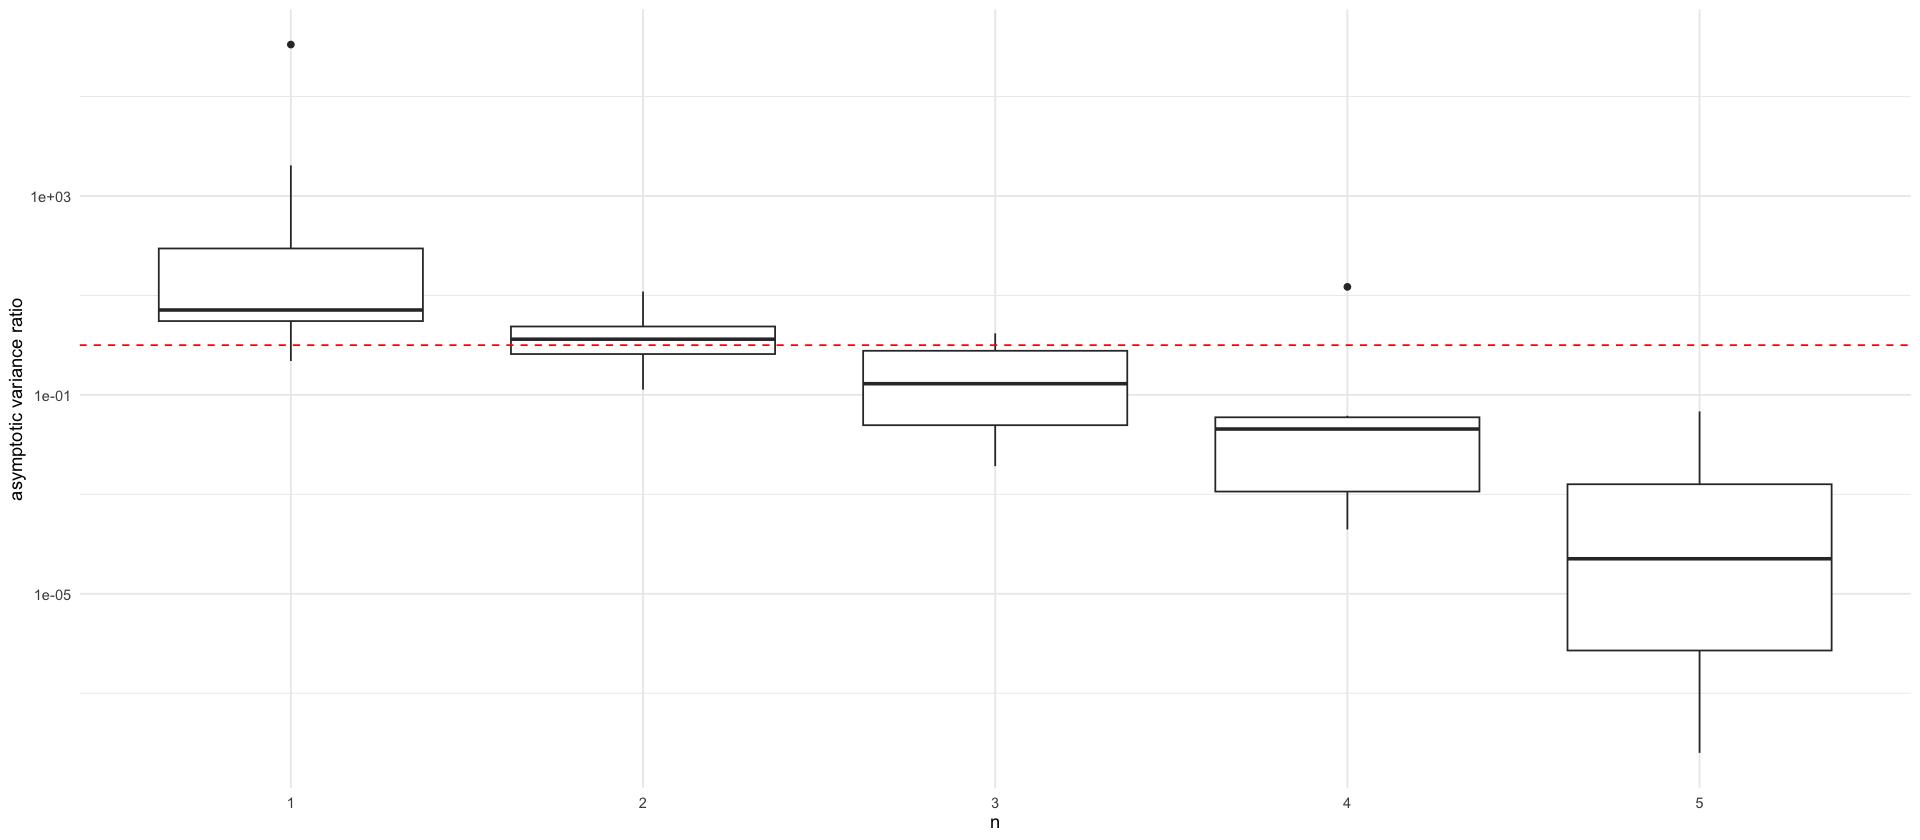

In [9]:
df_are <- read_csv(here("data/figures/are_meis_cem_ssms.csv"))
p_are <- df_are %>%
    filter(n <= 5) %>%
    # ARE here is for CEM vs. EIS ,we want EIS vs. CEM
    ggplot(aes(x = factor(n), y = 1/ARE)) +
    geom_boxplot() +
    labs(x = "n", y = "asymptotic variance ratio", color="") +
    geom_hline(yintercept = 1, linetype="dashed", color = "red") +
    scale_y_log10() 

ggsave_tikz(
    here("tikz/ssm_comparison_asymptotic_variance.tex"),
    plot = p_are
)
p_are

## Performance at the optimal proposal

### `tikz/rho_mu.tex`

agg_record_838534209 
                   2

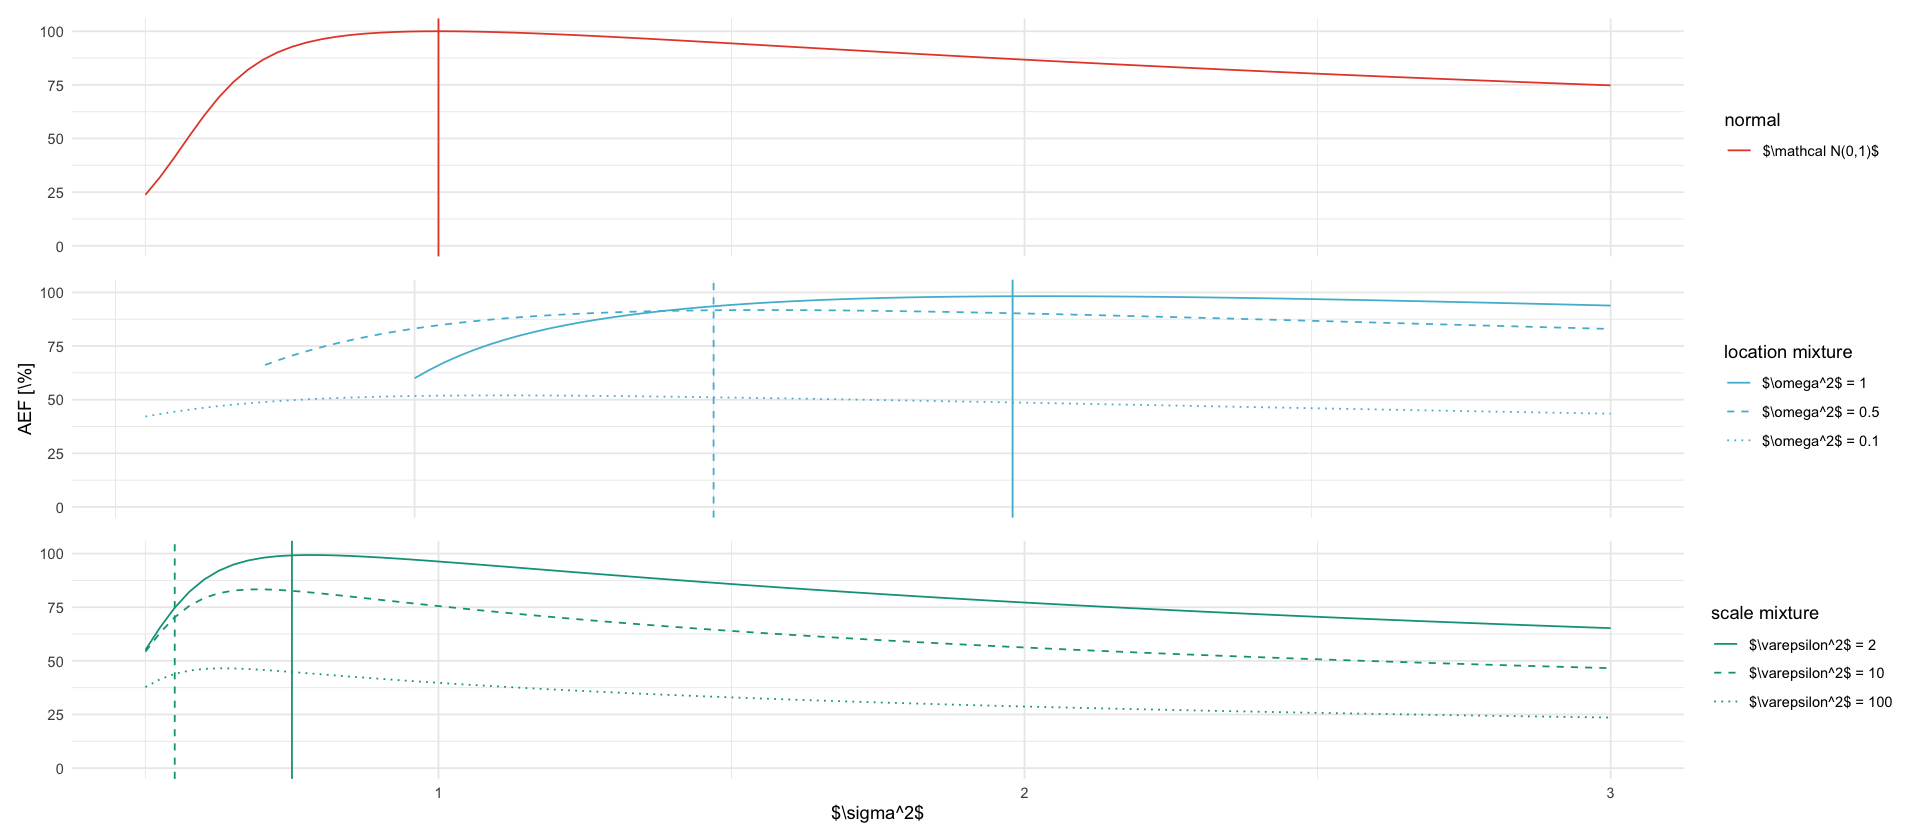

In [10]:
rho_s2_plots <- fixed_s2 %>%
    inner_join(targets_meta, by="P") %>%
    filter(tau2 / 2 <= s2) %>%
    group_by(type) %>%
    nest() %>%
    mutate(
        colors = case_when(
            type == "normal" ~ list(colors_normal),
            type == "location mixture" ~ list(colors_location),
            type == "scale mixture" ~ list(colors_scale)
        )
    ) %>%
    ungroup() %>%
    mutate(row_idx = row_number(), n_rows = n()) %>%
    mutate(
        plot = pmap(list(type, data, colors, row_idx, n_rows), function(type, data, colors, row_idx, n_rows) {
            color_scale <- scale_color_manual(values = colors)
            
            is_middle <- row_idx == ceiling(n_rows / 2)
            is_last <- row_idx == n_rows
            legend_title <- as.character(type)
            
            x_axis_theme <- if (!is_last) {
                theme(axis.title.x = element_blank(), axis.text.x = element_blank(), axis.ticks.x = element_blank())
            } else {
                theme()
            }
            
            y_label <- if (is_middle) "AEF [\\%]" else ""
            
            ggplot(data, aes(x=s2, y=ef_ce, color=description, linetype=description)) +
                geom_line() +
                geom_vline(
                    aes(xintercept = tau2, color=description, linetype=description), data = data %>% filter(abs(s2 - tau2) == min(abs(s2-tau2))), show.legend = FALSE) +
                target_linetypes +
                color_scale +
                labs(x="$\\sigma^2$", y=y_label, color=legend_title, linetype=legend_title) +
                ylim(0, 101) +
                theme(legend.position = "right") +
                x_axis_theme
        })
    )

rho_s2_plots$plot[[1]] / rho_s2_plots$plot[[2]] / rho_s2_plots$plot[[3]]

ggsave_tikz(here("tikz/rho_mu.tex"), width = 8, height = 5)

### `tikz/rho.tex`

Warning message:
“Removed 48 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 48 rows containing missing values or values outside the scale range
(`geom_line()`).”


agg_record_884808643 
                   2

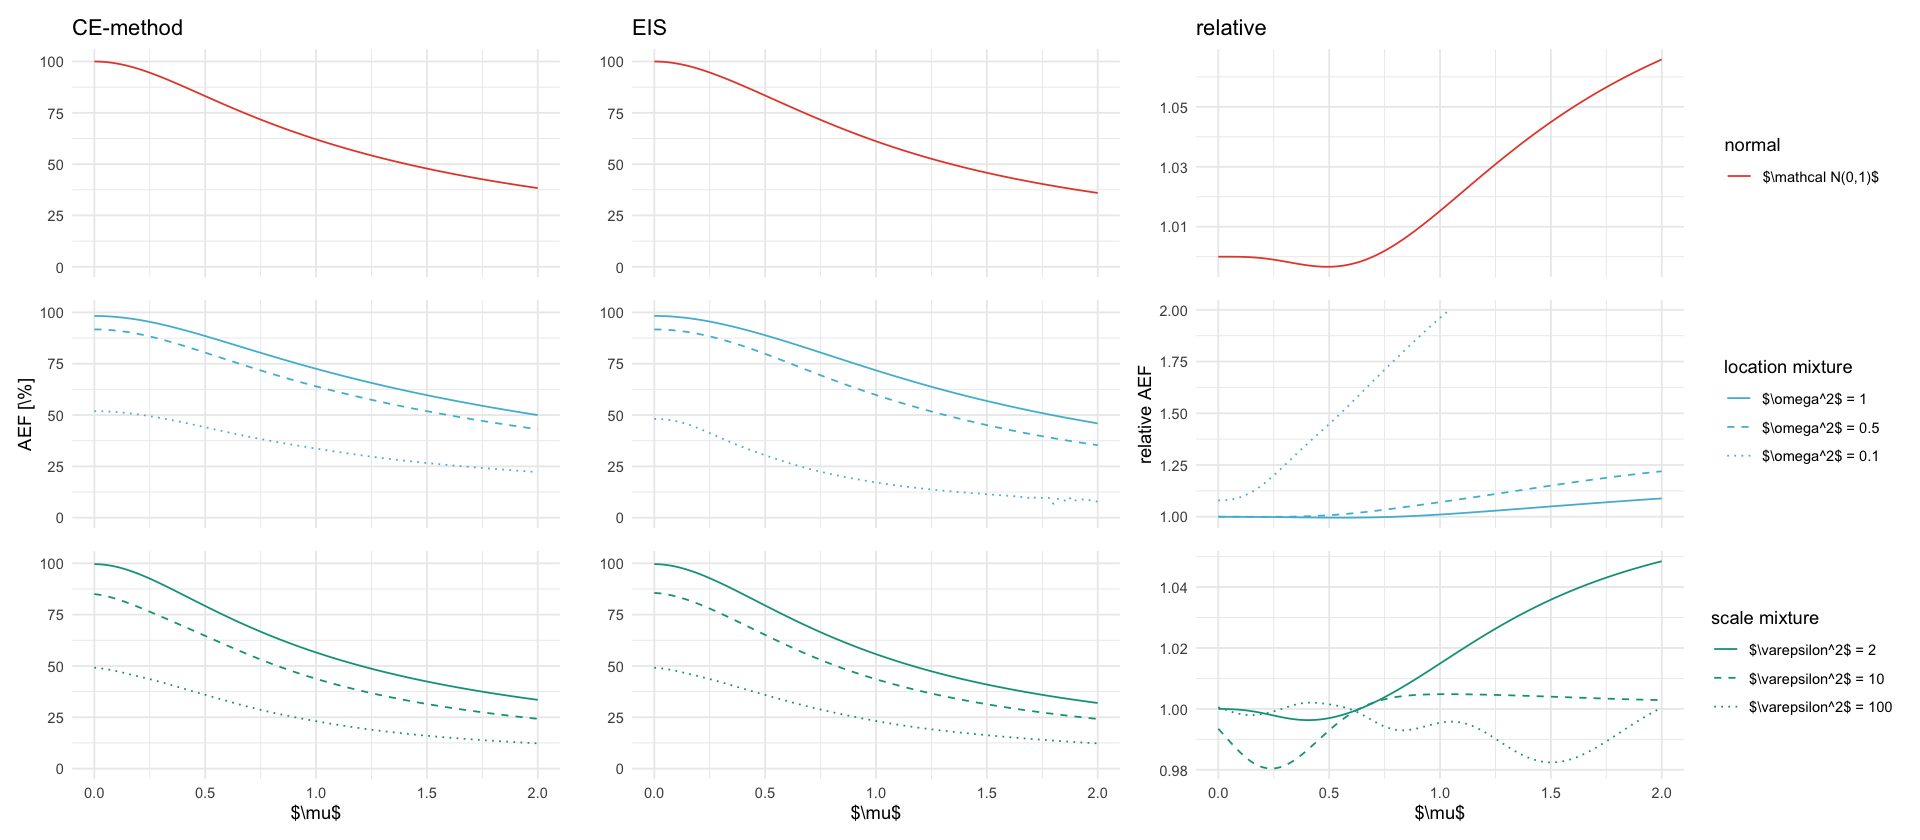

In [11]:
rho_plots <- fixed_mu %>%
    inner_join(targets_meta, by="P") %>%
    mutate(relative_ef = ifelse(ef_ce/ef_eis > 2, NA, ef_ce/ef_eis)) %>%
    group_by(type) %>%
    nest() %>%
    mutate(
        colors = case_when(
            type == "normal" ~ list(colors_normal),
            type == "location mixture" ~ list(colors_location),
            type == "scale mixture" ~ list(colors_scale)
        )
    ) %>%
    ungroup() %>%
    mutate(row_idx = row_number(), n_rows = n()) %>%
    mutate(
        plot = pmap(list(type, data, colors, row_idx, n_rows), function(type, data, colors, row_idx, n_rows) {
            color_scale <- scale_color_manual(values = colors)
            
            is_first <- row_idx == 1
            is_middle <- row_idx == ceiling(n_rows / 2)
            is_last <- row_idx == n_rows
            legend_title <- as.character(type)
            
            x_axis_theme <- if (!is_last) {
                theme(axis.title.x = element_blank(), axis.text.x = element_blank(), axis.ticks.x = element_blank())
            } else {
                theme()
            }
            
            title_ce <- if (is_first) "CE-method" else NULL
            title_eis <- if (is_first) "EIS" else NULL
            title_relative <- if (is_first) "relative" else NULL
            
            y_label_aef <- if (is_middle) "AEF [\\%]" else ""
            y_label_relative <- if (is_middle) "relative AEF" else ""
            
            p_ce <- ggplot(data, aes(x=mu, y=ef_ce, color=description, linetype=description)) +
                geom_line() +
                target_linetypes +
                color_scale +
                labs(x="$\\mu$", y=y_label_aef, color=legend_title, linetype=legend_title) +
                ylim(0, 101) +
                ggtitle(title_ce) +
                theme(legend.position = "bottom") +
                x_axis_theme
            
            p_eis <- ggplot(data, aes(x=mu, y=ef_eis, color=description, linetype=description)) +
                geom_line() +
                target_linetypes +
                color_scale +
                labs(x="$\\mu$", y="", color=legend_title, linetype=legend_title) +
                ylim(0, 101) +
                ggtitle(title_eis) +
                theme(legend.position = "bottom") +
                x_axis_theme
            
            p_relative <- ggplot(data, aes(x=mu, y=relative_ef, color=description, linetype=description)) +
                geom_line() +
                target_linetypes +
                color_scale +
                labs(x="$\\mu$", y=y_label_relative, color=legend_title, linetype=legend_title) +
                ggtitle(title_relative) +
                theme(legend.position = "bottom") +
                x_axis_theme
            
            (p_ce | p_eis | p_relative) + plot_layout(guides = "collect") & theme(legend.position = "right")
        })
    )

rho_plots$plot[[1]] / rho_plots$plot[[2]] / rho_plots$plot[[3]]

ggsave_tikz(here("tikz/rho.tex"), width=7, height= 10)

### maximum relative standard error

In [12]:
fixed_s2 %>%
    mutate(
        rel_se_ce = se_ce / var_ce * 100, 
        rel_se_eis = se_eis / var_eis * 100,
        rel_se_var_ratio = se_var_ratio / var_ratio * 100
    ) %>%
    select(
starts_with('rel_se')) %>%
    summarize(
        nanmax = max(., na.rm = T),
        n_nan = sum(is.na(rel_se_ce) + is.na(rel_se_eis) + is.na(rel_se_var_ratio))
    )

nanmax,n_nan
<dbl>,<int>
2.015104,2


### `tikz/ssm_comparison_efficiency_factor.tex`

Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


agg_record_1266120552 
                    2

Warning message:
“Removed 11 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


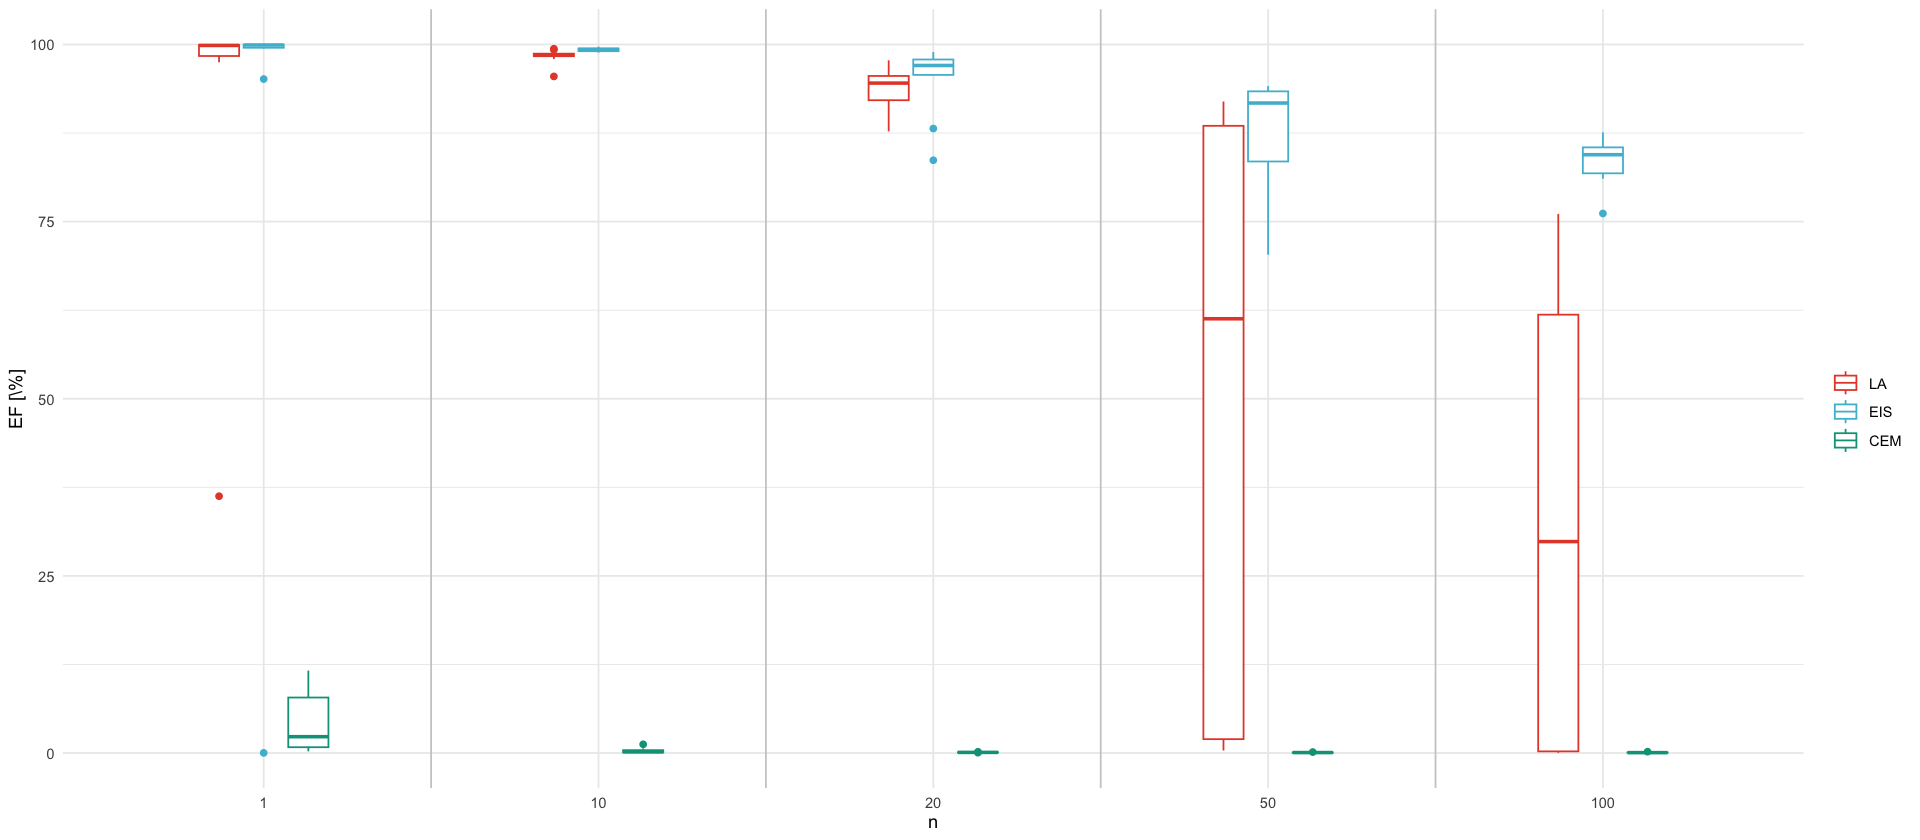

In [13]:
unique_n <- df_ef$n %>% unique() %>% sort()
p_ef <- df_ef %>%
    select(n, LA=EF_LA, CEM=EF_CEM, EIS=EF_MEIS) %>%
    pivot_longer(-n, names_to = "Method", values_to = "EF") %>%
    mutate(Method = factor(Method, levels=c("LA", "EIS", "CEM"))) %>%
    ggplot(aes(x = factor(n), y = EF, color = Method, group=interaction(factor(n), Method))) +
    geom_vline(xintercept = seq(1.5, length(unique_n) - 0.5, by = 1), color = "grey80", linewidth = 0.5) +
    geom_boxplot(width = 0.4) +
    labs(x = "n", y = "EF [\\%]", color="")

ggsave_tikz(
    here("tikz/ssm_comparison_efficiency_factor.tex"),
    plot = p_ef
)
p_ef

### `tables/ssm_comparison_missing_values.tex`

In [14]:
# count missing values per column on df_ef
df_ef %>%
    select(n, LA=EF_LA,EIS=EF_MEIS, CEM=EF_CEM) %>%
    group_by(n) %>%
    summarise(across(everything(), ~ sum(is.na(.)))) %>%
    kable(format="latex", booktabs=TRUE, linesep="") %>%
    cat(., file=here("tables/ssm_comparison_missing_values.tex"))